<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- KROK 1: Ładowanie danych ---
--- KROK 2: Podstawowe statystyki (Out-of-Domain) ---
Liczba przykładów: 5783
Liczba unikalnych etykiet: 4
Proporcje klas (Out-of-Domain):
target
__label__meta_amb        0.181567
__label__meta_minus_m    0.379388
__label__meta_plus_m     0.271140
__label__meta_zero       0.167906


--- KROK 3: Porównanie rozkładu klas ---
                       In-Domain  Out-of-Domain
target                                         
__label__meta_amb       0.181567       0.181567
__label__meta_minus_m   0.379388       0.379388
__label__meta_plus_m    0.271140       0.271140
__label__meta_zero      0.167906       0.167906

Wniosek: Proporcje klas są bardzo podobne.

--- KROK 4: Długość recenzji dla każdej klasy ---
                             mean  median
target                                   
__label__meta_amb      132.697143   111.0
__label__meta_minus_m  150.493163   125.0
__label__meta_plus_m   120.153699   105.5
__label__meta_zero     138.667353   136.0


--- K

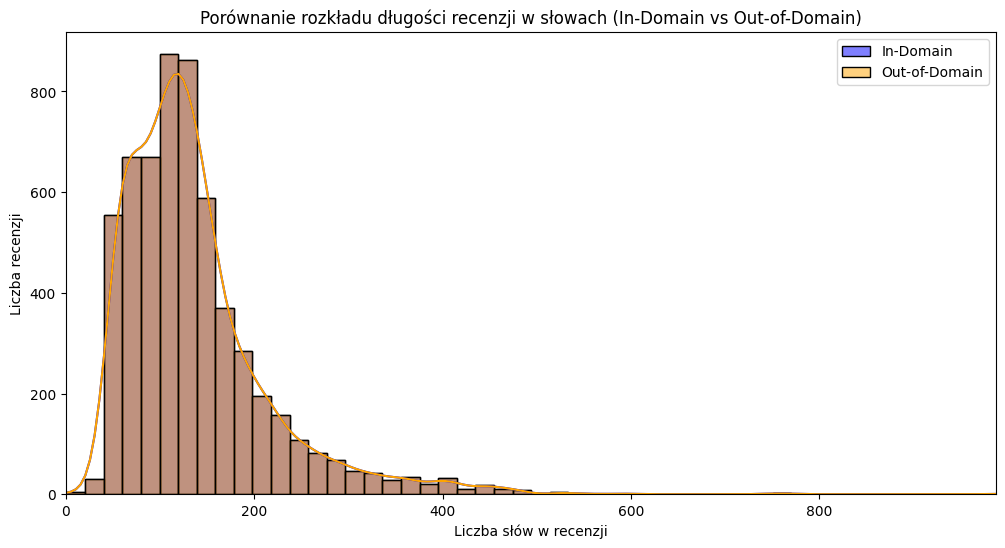



--- KROK 6: Najdłuższa i najkrótsza recenzja (Out-of-Domain) ---
Najdłuższa recenzja
Etykieta: __label__meta_minus_m | Liczba słów: 987
Treść:
Wybór sylwestrowego pakietu w tym hotelu za gigantyczne pieniądze ( jak na zaproponowane warunki i " atrakcje " ) to jeden z naszych największych błędów . Kierowali śmy się reklamami , ogłoszeniami i wizerunkiem hotelu , który kreuje się na mega luksusowy . . . Po 4 godzinach podróży z dzieckiem i kotem otrzymali śmy kartę do pokoju hotelowego . . . Kiedy do niego weszli śmy z wrażenia opadła m na łóżko , zaścielone pomiętą , wygniecioną pościelą . W pokoju . . . brud . Wykładzina poplamiona , w pokoju jedno okno , balkonowe , nieszczelne , problem z otwarciem ( jak wywietrzyć pokój , z jednym balkonowym oknem , którego nie można uchylić , kiedy przyjeżdża się z kotem ? ) na szybach skraplająca się woda , firanki pogniecione , pozaciągane , niedoprane . Stolik nocny z zepsutą szufladą . Abażury lampek mocno po przejściach , ściany obrzydliwie 

In [ ]:
!pip install -q datasets pandas matplotlib seaborn

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- KROK 1: Ładowanie danych ---")
dataset_out = load_dataset("allegro/klej-polemo2-out")
df_out = dataset_out['train'].to_pandas()
dataset_in = load_dataset("allegro/klej-polemo2-in")
df_in = dataset_in['train'].to_pandas()

print("--- KROK 2: Podstawowe statystyki (Out-of-Domain) ---")
print(f"Liczba przykładów: {len(df_out)}")
print(f"Liczba unikalnych etykiet: {df_out['target'].nunique()}")

class_proportions_out = df_out['target'].value_counts(normalize=True).sort_index()
print("Proporcje klas (Out-of-Domain):")
print(class_proportions_out.to_string())
print("\n")

print("--- KROK 3: Porównanie rozkładu klas ---")
class_proportions_in = df_in['target'].value_counts(normalize=True).sort_index()

comparison_df = pd.DataFrame({
    'In-Domain': class_proportions_in,
    'Out-of-Domain': class_proportions_out
})
print(comparison_df)
print("\nWniosek: Proporcje klas są bardzo podobne.\n")


print("--- KROK 4: Długość recenzji dla każdej klasy ---")
df_out['word_count'] = df_out['sentence'].apply(lambda x: len(str(x).split()))
df_in['word_count'] = df_in['sentence'].apply(lambda x: len(str(x).split())) # dla kroku 5

length_stats = df_out.groupby('target')['word_count'].agg(['mean', 'median'])
print(length_stats)
print("\n")

print("--- KROK 5: Generowanie histogramu ---")
plt.figure(figsize=(12, 6))
sns.histplot(df_in['word_count'], color='blue', alpha=0.5, label='In-Domain', bins=50, kde=True)
sns.histplot(df_out['word_count'], color='orange', alpha=0.5, label='Out-of-Domain', bins=50, kde=True)
plt.title('Porównanie rozkładu długości recenzji w słowach (In-Domain vs Out-of-Domain)')
plt.xlabel('Liczba słów w recenzji')
plt.ylabel('Liczba recenzji')
plt.legend()
plt.xlim(0, max(df_in['word_count'].max(), df_out['word_count'].max()))
plt.show()
print("\n")

print("--- KROK 6: Najdłuższa i najkrótsza recenzja (Out-of-Domain) ---")

idx_max = df_out['word_count'].idxmax()
idx_min = df_out['word_count'].idxmin()

longest_review = df_out.loc[idx_max]
shortest_review = df_out.loc[idx_min]

print(f"Najdłuższa recenzja")
print(f"Etykieta: {longest_review['target']} | Liczba słów: {longest_review['word_count']}")
print(f"Treść:\n{longest_review['sentence']}\n")

print(f"Najkrótsza recenzja")
print(f"Etykieta: {shortest_review['target']} | Liczba słów: {shortest_review['word_count']}")
print(f"Treść:\n{shortest_review['sentence']}")